### Lab IV: Linear Models
### Answer all three sets of questions

#### Turn in one python file for the three computation questions and one text file for Q0

**Q0.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (This is a trick question, and the trick involves how you handle the intercept of the model.) There's further explanation at the end of this document, if needed.
3. Can linear regression be used for classification? Explain why, or why not.
4. If you have a high accuracy on testing but low on testing, what might be the problem? It also might be you see a pattern in the residuals. 
5. Review this page: [Non-Linear with Linear](https://inria.github.io/scikit-learn-mooc/python_scripts/linear_regression_non_linear_link.html) What are two ways to incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$?
6. What is the interpretation of the intercept? A slope coefficient for a variable? The coefficient for a dummy/one-hot-encoded variable?

**A0.**

1. A model is linear when it assumes a linear relationship between the variables. It is linear in its parameters and the predictor variable X. 
2. When intercept is included, the dummy coefficient represents the difference between that category’s mean and the reference group’s mean. When intercept is excluded and all categories are included, the coefficient represents the absolute mean of that category.
3. Technically linear regression can be used for classification, but is usually unsuitable compared to logisitc regression. When used for classification, it takes binary values (0 and 1) and treats them like continuous numbers, trying to fit a straight line through them. This makes it prone to misclassification, very sensitive to outliers, and can create poor probability estimates. 
4. High accuracy on testing but low on testing means that it is overfitting. The problem may be because the model learns specific noise from the training data. When there is a pattern in the residuals, that may mean that there is no linear relationship or the model's error variance is not constant. 
5. To incorporate nonlinear relationships you can create a richer set of features derived from the original data that can be used by a simple linear model, or use a "kernel" to create a locally-based decision function instead of a global linear one.
6. The intercept is the expected mean value of the dependent variable when all the independent variables are zero. The slope is the average change in in the dependent variable for every one unit increase in the independent variable (when all other variables are constant). The coefficient for a dummy variable is either the difference in mean between the specific category and the baseline category, or the absolute mean for the specific category. 

**Q1.** Load clean q1_clean: https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv 

The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighborhood `: The bourough of NYC. Note the space, or rename the variable.
- `Property Type`: The kind of dwelling
- `Room Type`: The kind of space being rented

1. Compute the average prices and scores by `Neighborhood `; which borough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighborhood `.
2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of a continuous variable on one categorical variable?
3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?
4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the $R^2$ and RMSE on the test set? What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?
6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? Hint: Think about how multiple linear regression works.
7. (Optional) We've included `Neighborhood ` and `Property Type` separately in the model. How do you interact them, so you can have "A bedroom in Queens" or "A townhouse in Manhattan". Split the sample 80/20 into a training and a test set and run a regression including that kind of "property type X neighborhood" dummy, plus `Review Scores Rating`. How does the slope coefficient for `Review Scores Rating`, the $R^2$, and the RMSE change? Do they increase significantly compares to part 5? Are the coefficients in this regression just the sum of the coefficients for `Neighbourhood ` and `Property Type` from 5? What is the most expensive kind of property you can rent?

In [1]:
# import dependencies
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures

In [2]:
# load data
q1_clean = pd.read_csv('https://raw.githubusercontent.com/DS3001/linearRegression/refs/heads/main/data/Q1_clean.csv ')
# renaming column 
q1_clean = q1_clean.rename(columns = {'Neighbourhood ':'Neighborhood'})
q1_clean.head()

,Price,Review Scores Rating,Neighborhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


                    Price  Review Scores Rating
Neighborhood                                   
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378
Most expensive borough on average: Manhattan


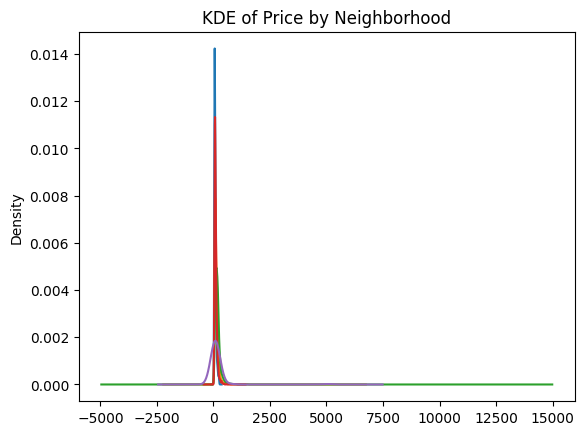

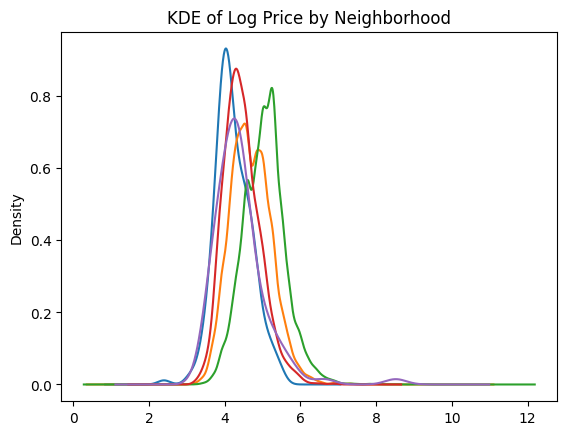

In [3]:
# 1. Compute the average prices and scores by Neighborhood ; which borough is the most expensive on average? 
# Create a kernel density plot of price and log price, grouping by Neighborhood.

stats = q1_clean.groupby('Neighborhood')[['Price', 'Review Scores Rating']].mean()
print(stats.sort_values('Price', ascending = False))
# most expensive borough on average
most_expensive_borough = stats['Price'].idxmax()
print('Most expensive borough on average:', most_expensive_borough)

# KDE plot of price by neighborhood
q1_clean.groupby('Neighborhood')['Price'].plot.kde(title = "KDE of Price by Neighborhood")
plt.show()

# KDE plot of log price by neighborhood
q1_clean['Log_Price'] = np.log(q1_clean['Price'] + 1)
q1_clean.groupby('Neighborhood')['Log_Price'].plot.kde(title = "KDE of Log Price by Neighborhood")
plt.show()

In [4]:
# 2. Regress price on `Neighborhood ` by creating the appropriate dummy/one-hot-encoded variables, without an intercept in the linear model. 
# Compare the coefficients in the regression to the table from part 1. What pattern do you see? What are the coefficients in a regression of 
# a continuous variable on one categorical variable?

# dummy variables
no_int = pd.get_dummies(q1_clean, columns = ['Neighborhood'], prefix = ['Nb'])

# regression without intercept
X_no_int = no_int.filter(like = 'Nb_')
y_target = no_int['Price']

model_no_int = LinearRegression(fit_intercept = False).fit(X_no_int, y_target)
print(model_no_int.coef_)

# The intercepts are the same as the mean prices for each neighborhood, which is expected since it was regressed without an intercept. 
# The coefficients of a continuous variable on one categorical variable are the absolute mean of each category. 

[ 75.2764977  127.74737834 183.66428632  96.8572327  146.16666667]


In [5]:
# 3. Repeat part 2, but leave an intercept in the linear model. How do you have to handle the creation of the dummies differently? 
# What is the intercept? Interpret the coefficients. How can I get the coefficients in part 2 from these new coefficients?

# dummy variables
with_int = pd.get_dummies(q1_clean, columns = ['Neighborhood'],drop_first = True, prefix = ['Nb'])

# regression with intercept
X_with_int = with_int.filter(like = 'Nb_')

model_with_int = LinearRegression(fit_intercept = True).fit(X_with_int, y_target)
print(model_with_int.intercept_)
print(model_with_int.coef_)

# Handle the creation of dummies differently by dropping the first category to avoid multicollinearity. The intercept is mean price of the dropped
# category. The coefficients represent the difference in mean price between each neighborhood and the dropped category. 
# You can get the coefficients in part 2 by adding the intercept to each of the coefficients in part 3. 

75.27649769585331
[ 52.47088065 108.38778863  21.58073501  70.89016897]


In [6]:
# 4. Split the sample 80/20 into a training and a test set. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood `.
# What is the R^2 and RMSE on the test set? What is the coefficient on `Review Scores Rating`? 
# What is the most expensive kind of property you can rent?

# selecting features and getting dummies
features = q1_clean[['Price', 'Review Scores Rating', 'Neighborhood']].copy()
encoded = pd.get_dummies(features, columns = ['Neighborhood'], drop_first = True, prefix = 'Nb')

# splitting the data
train, test = train_test_split(encoded, test_size = 0.2, random_state = 42)

# separating
X_train = train.drop(columns = ['Price'])
y_train = train['Price']

X_test = test.drop(columns = ['Price'])
y_test = test['Price']

# regression
model = LinearRegression().fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Coefficient on Review Scores Rating: {model.coef_[0]:.4f}")

# most expensive kind of property
coef_df = pd.DataFrame({'Feature': X_train.columns, 'Coef': model.coef_})
print(coef_df.sort_values('Coef', ascending = False).head())

# The most expensive kind of property you can rent is in the dummy variable with the highest positive coefficient, 
# which is the neighborhood with the highest average price; Manhattan. 

Mean Squared Error: 19857.94
RMSE: 140.92
R² Score: 0.0459
Coefficient on Review Scores Rating: 1.2119
                Feature        Coef
2          Nb_Manhattan  107.413553
1           Nb_Brooklyn   51.555970
4      Nb_Staten Island   23.454672
3             Nb_Queens   20.198573
0  Review Scores Rating    1.211852


In [7]:
# 5. Run a regression of `Price` on `Review Scores Rating` and `Neighborhood ` and `Property Type`. What is the R^2 and RMSE on the test set? 
# What is the coefficient on `Review Scores Rating`? What is the most expensive kind of property you can rent?

# selecting features and getting dummies
features2 = q1_clean[['Price', 'Review Scores Rating', 'Neighborhood', 'Property Type']].copy()
encoded2 = pd.get_dummies(features2, columns = ['Neighborhood', 'Property Type'], drop_first = True, prefix = ['Nb', 'Prop'])

# splitting the data
train2, test2 = train_test_split(encoded2, test_size = 0.2, random_state = 42)

# separating
X_train2 = train2.drop(columns = ['Price'])
y_train2 = train2['Price']

X_test2 = test2.drop(columns = ['Price'])
y_test2 = test2['Price']

# regression
model2 = LinearRegression().fit(X_train2, y_train2)

y_pred2 = model2.predict(X_test2)

mse = mean_squared_error(y_test2, y_pred2)
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred2)
print(f"Mean Squared Error: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Coefficient on Review Scores Rating: {model2.coef_[0]:.4f}")

# most expensive kind of property
coef_df2 = pd.DataFrame({'Feature': X_train2.columns, 'Coef': model2.coef_})
print(coef_df2.sort_values('Coef', ascending = False).head())

# The most expensive kind of property you can rent is still a property in Manhattan, but the most expensive property type is a bungalow. 

Mean Squared Error: 19684.84
RMSE: 140.30
R² Score: 0.0542
Coefficient on Review Scores Rating: 1.2010
             Feature        Coef
2       Nb_Manhattan  121.005520
7      Prop_Bungalow   83.972440
17         Prop_Loft   69.891025
12  Prop_Condominium   61.907162
1        Nb_Brooklyn   59.633702


In [8]:
# 6. What does the coefficient on `Review Scores Rating` mean if it changes from part 4 to 5? 
# Hint: Think about how multiple linear regression works.

# The coefficient changing means that the relationship between scores and price is not the same across all property types and neighborhoods. 
# In part 4, the model saw high prices and high ratings and assumed the ratings were causing the high price.
# in part 5 the model accounts for the effect of a rating, holding the property type constant.

**Q2.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`, `Color`, `Seating_Capacity`
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make`, `Make_Year`: The brand of car and year produced
  - `Mileage_Run`: The number of miles on the odometer
  - `Fuel_Type`: Diesel or gasoline/petrol
  - `Transmission`, `Transmission_Type`:  speeds and automatic/manual

  1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.
  2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?
  3. Split the data into an 80% training set and a 20% testing set.
  4. Make a model where you regress price on the numeric variables alone; what is the $R^2$ and `RMSE` on the training set and test set? Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the $R^2$ and `RMSE` on the test set? Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; what is the $R^2$ and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?
  5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression. As you increase the degree of the expansion, how do the $R^2$ and `RMSE` change? At what point does $R^2$ go negative on the test set? For your best model with expanded features, what is the $R^2$ and `RMSE`? How does it compare to your best model from part 4?
  6. For your best model so far, determine the predicted values for the test data and plot them against the true values. Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

In [9]:
# 1. Load `cars_hw.csv`. These data were really dirty, and I've already cleaned them a significant amount in terms of missing values and other issues, 
# but some issues remain (e.g. outliers, badly skewed variables that require a log or arcsinh transformation) Note this is different than 
# normalizing: there is a text below that explains further. Clean the data however you think is most appropriate.

cars = pd.read_csv('cars_hw.csv')
cars.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


               count          mean           std        min        25%  \
Make                                                                     
MG Motors       35.0  1.869457e+06  1.216611e+05  1589000.0  1786500.0   
Kia              8.0  1.614750e+06  1.190567e+05  1369000.0  1579000.0   
Jeep             4.0  1.499500e+06  1.525134e+05  1290000.0  1447500.0   
Skoda            5.0  1.136000e+06  1.070175e+06   436000.0   466000.0   
Mahindra        18.0  1.100167e+06  1.755493e+05   796000.0  1037000.0   
Tata            23.0  1.055217e+06  5.578305e+05   188000.0   779500.0   
Nissan           4.0  8.842500e+05  2.895599e+05   475000.0   782500.0   
Toyota          50.0  8.003400e+05  2.466900e+05   368000.0   526250.0   
Honda           73.0  7.989726e+05  2.665091e+05   316000.0   581000.0   
Ford            52.0  7.211731e+05  1.409277e+05   290000.0   635000.0   
Hyundai        305.0  6.918918e+05  2.791597e+05   248000.0   485000.0   
Renault         68.0  6.625735e+05  2.

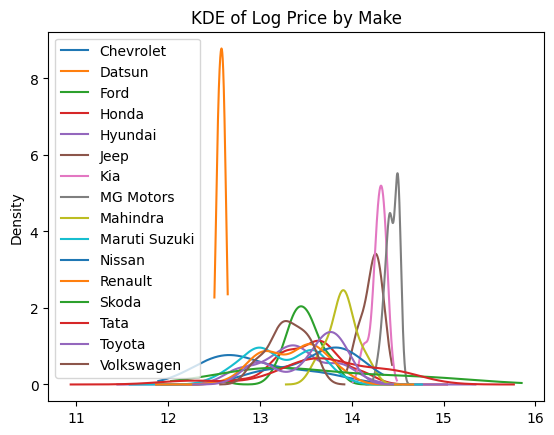

In [10]:
# 2. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by brand (`Make`). 
# Make a grouped kernel density plot by `Make`. Which car brands are the most expensive? What do prices look like in general?

# summarize
print(cars.groupby('Make')['Price'].describe().sort_values('mean', ascending = False))

# KDE plot
# log
cars['Log_Price'] = np.log(cars['Price'] + 1)

cars.groupby('Make')['Log_Price'].plot.kde(title = "KDE of Log Price by Make", legend = True)
plt.show()

# MG Motors is the most expensive on average. A few makes are more left skewed, but most of them look pretty symmetric. 

In [11]:
# 3. Split the data into an 80% training set and a 20% testing set.

train, test = train_test_split(cars, test_size = 0.2, random_state = 42)

In [12]:
# 4. Make a model where you regress price on the numeric variables alone; what is the R^2 and `RMSE` on the training set and test set? 
# Make a second model where, for the categorical variables, you regress price on a model comprised of one-hot encoded regressors/features 
# alone (you can use `pd.get_dummies()`; be careful of the dummy variable trap); what is the R^2 and `RMSE` on the test set? 
# Which model performs better on the test set? Make a third model that combines all the regressors from the previous two; 
# what is the R^2 and `RMSE` on the test set? Does the joint model perform better or worse, and by home much?

# selecting numerical columns
num_cols = ['Make_Year', 'Mileage_Run', 'Seating_Capacity']
# regression
model_num = LinearRegression().fit(train[num_cols], train['Price'])
# finding R^2 and RMSE on train set
y_train_pred = model_num.predict(train[num_cols])
mse_train = mean_squared_error(train['Price'], y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(train['Price'], y_train_pred)

print(f"RMSE for train: {rmse_train:.2f}")
print(f"R² Score for train: {r2_train:.4f}")
# finding R^2 and RMSE on test set
y_test_pred = model_num.predict(test[num_cols])
mse_test = mean_squared_error(test['Price'], y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(test['Price'], y_test_pred)

print(f"RMSE for test; Numerical: {rmse_test:.2f}")
print(f"R² Score for test; Numerical: {r2_test:.4f}")


# selecting categorical columns and getting dummies
cat_cols = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
encoded_cat = pd.get_dummies(cars[cat_cols + ['Price']], drop_first = True)
# split
train_cat, test_cat = train_test_split(encoded_cat, test_size = 0.2, random_state = 42)
# separate
X_train_cat = train_cat.drop('Price', axis=1)
y_train_cat = train_cat['Price']

X_test_cat = test_cat.drop('Price', axis=1)
y_test_cat = test_cat['Price']
# regression
model_cat = LinearRegression().fit(X_train_cat, y_train_cat)
# finding R^2 and RMSE on test set
y_pred_cat = model_cat.predict(X_test_cat)
mse_cat = mean_squared_error(y_test_cat, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
r2_cat = r2_score(y_test_cat, y_pred_cat)

print(f"RMSE for categorical model: {rmse_cat:.2f}")
print(f"R² Score for categorical model: {r2_cat:.4f}")

# The model with only categorical variables performs better on the test set than the model with only numerical variables.

# All regressors
df_joint = pd.get_dummies(cars[num_cols + cat_cols + ['Price']], drop_first = True)
train_j, test_j = train_test_split(df_joint, test_size = 0.2, random_state = 42)
# regression
model_j = LinearRegression().fit(train_j.drop('Price', axis = 1), train_j['Price'])
# RMSE and R^2 on test set
y_pred_joint = model_j.predict(test_j.drop('Price', axis = 1))
mse_joint = mean_squared_error(test_j['Price'], y_pred_joint)
rmse_joint = np.sqrt(mse_joint)
r2_joint = r2_score(test_j['Price'], y_pred_joint)

print(f"RMSE for joint model: {rmse_joint:.2f}")
print(f"R² Score for joint model: {r2_joint:.4f}")

# The joint model performs better than both others. The RMSE reduced by 39,215.91 and increased R^2 by 0.1116. 

RMSE for train: 309338.37
R² Score for train: 0.3144
RMSE for test; Numerical: 284546.95
R² Score for test; Numerical: 0.2941
RMSE for categorical model: 182791.11
R² Score for categorical model: 0.7087
RMSE for joint model: 143575.20
R² Score for joint model: 0.8203


In [13]:
# 5. Use the `PolynomialFeatures` function from `sklearn` to expand the set of numerical variables you're using in the regression.
# As you increase the degree of the expansion, how do the R^2 and `RMSE` change? At what point does R^2 go negative on the test set? 
# For your best model with expanded features, what is the R^2 and `RMSE`? How does it compare to your best model from part 4?

for d in range(1, 6):
    poly = PolynomialFeatures(degree = d)
    
    # separate
    X_train_poly = poly.fit_transform(train[num_cols])
    X_test_poly = poly.transform(test[num_cols])
    
    # regression
    model_poly = LinearRegression().fit(X_train_poly, train['Price'])
    
    # R^2 and RMSE
    y_poly_pred = model_poly.predict(X_test_poly)
    r2_poly = r2_score(test['Price'], y_poly_pred)
    rmse_poly = np.sqrt(mean_squared_error(test['Price'], y_poly_pred))
    
    print(f"Degree {d}: R² = {r2_poly:.4f}, RMSE = {rmse_poly:.2f}")

# As the degree increases, the R^2 went up and then down after degree 2. The RMSE went down and then up after degree 2. The R^2 never goes negative
# in degrees 1 to 5. Degree 2: R² = 0.3269, RMSE = 277849.79. The joint model (the best model from part 4) is still better than the best 
# polynomial model. 

Degree 1: R² = 0.2941, RMSE = 284546.95
Degree 2: R² = 0.3269, RMSE = 277849.79
Degree 3: R² = 0.3115, RMSE = 281003.61
Degree 4: R² = 0.3079, RMSE = 281751.62
Degree 5: R² = 0.2911, RMSE = 285141.53


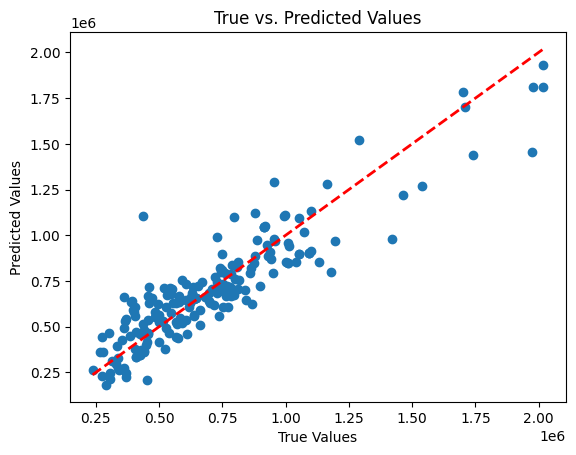

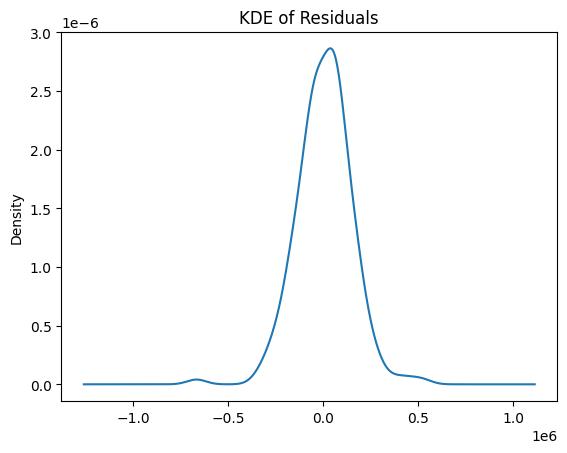

In [14]:
# 6. For your best model so far, determine the predicted values for the test data and plot them against the true values. 
# Do the predicted values and true values roughly line up along the diagonal, or not? Compute the residuals/errors for the test data and 
# create a kernel density plot. Do the residuals look roughly bell-shaped around zero? Evaluate the strengths and weaknesses of your model.

# predicted values
y_pred_best = model_j.predict(test_j.drop('Price', axis = 1))
y_true = test_j['Price']

# plot predicted vs true values
plt.scatter(y_true, y_pred_best)
plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], '--r', linewidth=2)
plt.xlabel('True Values')
plt.ylabel('Predicted Values')
plt.title('True vs. Predicted Values')
plt.show()

# The predicted values and true values do roughly line up along the diagonal, which indicates a good fit. 

# residuals
residuals = y_true - y_pred_best

# KDE plot
residuals.plot.kde(title = "KDE of Residuals")
plt.show()

# The residuals do look roughly bell shaped around 0. 

# Strengths: relatively high R^2, one-hot encoding 'Make' allows the model to capture the differences in price across different brands, 
# easy to interpret coefficients, and the residuals look normally distributed.
# Weaknesses: it assumes every mile driven reduces the price by the same amount, sensitive to outliers, does not capture non-linear relationships. 

**Q3.**
1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.
2. Clean the data and do some exploratory data analysis on key variables that interest you. Pick a particular target/outcome variable and features/predictors.
3. Split the sample into an ~80% training set and a ~20% test set.
4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.
5. Which model performed the best, and why?
6. What did you learn?

In [15]:
# 1. Find a dataset on a topic you're interested in. Some easy options are data.gov, kaggle.com, and data.world.

import kagglehub
path = kagglehub.dataset_download("i0taiisquare/mens-wrist-watches-dataset")

watches = pd.read_csv(path + "/Amazon_Men_Wrist_Watches.csv")
watches.head()

/workspaces/Linear-Models-Lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,Unnamed: 0,brand_name,watch_name,rating,number_of_reviews,price
0,0,Casio,Vintage A-158WA-1Q Digital Grey Dial Unisex Wa...,4.4,54K,"1,894"
1,1,Casio,Youth Series Digital Black Dial Unisex Watch -...,4.5,13.2K,"1,191"
2,2,Titan,Karishma Analog Black Dial Men's Watch -NM1639...,4.3,2.9K,"1,695"
3,3,Daniel Hechter,Paris Bercy Collection Modern Multi Functional...,4.3,890,"2,593"
4,4,Casio,Unisex-Adult Vintage B650WC-5ADF Rose Gold Dig...,4.5,1.1K,"4,494"


In [16]:
# 2. Clean the data and do some exploratory data analysis on key variables that interest you. 
# Pick a particular target/outcome variable and features/predictors.

# convert price column to numeric
watches['price'] = watches['price'].astype(str).str.replace(r'[$, ]', '', regex = True)
watches['price'] = pd.to_numeric(watches['price'], errors = 'coerce')
watches = watches.dropna(subset = ['price'])

# get rid of 'k' and ',' in number of reviews and convert to numeric
watches['number_of_reviews'] = pd.to_numeric(watches['number_of_reviews'].str.replace('k', 'e3', case = False).str.replace(',', ''), errors = 'coerce')

# summarize price by brand
print(watches.groupby('brand_name')['price'].describe().sort_values('mean', ascending = False))

# target variable: price
target = 'price'
# features/predictors: brand_name, number_of_reviews, rating
features = ['brand_name', 'number_of_reviews', 'rating']

df_final = watches[features + [target]].dropna()

                       count       mean           std      min      25%  \
brand_name                                                                
Versace                  1.0  99260.000           NaN  99260.0  99260.0   
Swiss Military Hanowa    8.0  79832.375  46381.946488  36750.0  51546.5   
OBLVLO                   1.0  74978.000           NaN  74978.0  74978.0   
Philipp Plein            1.0  72500.000           NaN  72500.0  72500.0   
AGELOCER                 2.0  70793.000  21720.906104  55434.0  63113.5   
...                      ...        ...           ...      ...      ...   
LAVISHABLE               1.0    249.000           NaN    249.0    249.0   
STARGAZE                 1.0    205.000           NaN    205.0    205.0   
Talgo                    2.0    199.000      0.000000    199.0    199.0   
SELLORIA                 8.0    186.625     34.997704    162.0    167.5   
GENERIC                  1.0    148.000           NaN    148.0    148.0   

                        

In [17]:
# 3. Split the sample into an ~80% training set and a ~20% test set.

# one-hot encode brand name
df_final = pd.get_dummies(df_final, columns = ['brand_name'], drop_first = True)

# split
train, test = train_test_split(df_final, test_size = 0.2, random_state = 42)

In [18]:
# 4. Run a few regressions of your target/outcome variable on a variety of features/predictors. Compute the RMSE on the test set.

# numerical only
# numerical features
num = ['number_of_reviews', 'rating']
# separate
X_train_num = train[num]
y_train_num = train[target]
# regression
model_num = LinearRegression().fit(X_train_num, y_train_num)
# RMSE
rmse_num = np.sqrt(mean_squared_error(test['price'], model_num.predict(test[num])))
print(f"RMSE for numerical model: {rmse_num:.2f}")


# categorical only
cat = ['brand_name']
# separate
X_train_cat = train.drop(columns = ['number_of_reviews', 'rating', 'price'])
y_train_cat = train['price']
# regression
model_cat = LinearRegression().fit(X_train_cat, y_train_cat)
# RMSE
rmse_cat = np.sqrt(mean_squared_error(test['price'], model_cat.predict(test.drop(columns = ['number_of_reviews', 'rating', 'price']))))
print(f"RMSE for categorical model: {rmse_cat:.2f}")


# joint features
# separate
X_train_joint = train.drop(columns = ['price'])
y_train_joint = train['price']
# regression
model_joint = LinearRegression().fit(X_train_joint, y_train_joint)
# RMSE
rmse_joint = np.sqrt(mean_squared_error(test['price'], model_joint.predict(test.drop(columns = ['price']))))
print(f"RMSE for joint model: {rmse_joint:.2f}")

RMSE for numerical model: 8823.90
RMSE for categorical model: 5692.92
RMSE for joint model: 5661.76


In [19]:
# 5. Which model performed the best, and why?

# The joint model performed the best having the lowest RMSE. This likely because it captures more variation in price by including both numerical
# and categorical features. In my model, I only had one categorical variable which was the brand of the watch. Looking at the RMSE, you can see
# that the brand of the watch is a very strong predictor of price which is why both the joint and categorical model perform better. 

In [ ]:
# 6. What did you learn?

# I learned about how regression works with categorical variables and how to interpret the coefficients. I saw just how important it is to include
# any type of variable to a model in the case that it is a strong predictor of the outcome variable. I learned how to evaluate R^2 and RMSE to 
# determine the best model. I also reinforced my understanding and ability to clean data and do EDA. 

### Dummy Variable Trap 


In linear regression with categorical variables you should be careful of the Dummy Variable Trap. 
The Dummy Variable trap is a scenario in which the independent variables are multicollinear - a 
scenario in which two or more variables are highly correlated; in simple terms one variable can 
be predicted from the others. This can produce singularity of a model, meaning your model just won't 
work. Read about it below:

Idea is to use dummy variable encoding with drop_first=True, this will omit one column from each 
category after converting categorical variable into dummy/indicator variables. You WILL NOT lose 
and relevant information by doing that simply because your all point in dataset can fully be 
explained by rest of the features.

Here is complete code on how you can do it for a "jobs" dataset

So you have your X features:

Age, Gender, Job, Classification 

And one numerical features that you are trying to predict:

Wage

First you need to split your initial dataset on input variables and prediction, 
assuming its pandas dataframe it would look like this:

Input variables (your dataset is bit different but whole code remains the same, 
you will put every column from dataset in X, except one that will go to Y. pd.get_dummies 
works without problem like that - it will just convert categorical variables and it won't 
touch numerical):

X = jobs[['Age','Gender','Job','Classification']]

Prediction:

Y = jobs['Wage']

Convert categorical variable into dummy/indicator variables and drop one in each category:

X = pd.get_dummies(data=X, drop_first=True)

So now if you check shape of X (X.shape) with drop_first=True you will see that it has 
4 columns less - one for each of your categorical variables.

You can now continue to use them in your linear model. For scikit-learn implementation it 
could look like this:


In [21]:
from sklearn import linear_model
from sklearn.model_selection import train_test_split
    
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = .20, random_state = 40)
    
regr = linear_model.LinearRegression() # Do not use fit_intercept = False if you have removed 1 column after dummy encoding

regr.fit(X_train, Y_train)
predicted = regr.predict(X_test)

NameError: name 'X' is not defined

### Transformation versus Normalization

Use a **log transformation** when your data is strictly positive and heavily skewed towards larger values (right-skewed), while an **arcsinh transformation** is better suited for data with both positive and negative values, or when you need to handle potential zero values; **normalize** your data when you need to scale all values to a similar range, typically between 0 and 1, and especially when using algorithms sensitive to feature scale, but not necessarily to achieve a **normal distribution**. 
Key points about each transformation: 

    Log transformation: 

    Best for positively skewed data with large variations in magnitude. 

Useful when analyzing relative changes rather than absolute differences. 
Cannot handle negative values. 

Arcsinh transformation:

    Can handle both positive and negative data. 

Effective for data with extreme values on both ends of the spectrum. 
Often used when dealing with proportions or percentages near 0 or 1. 

Normalization: 

    Scales data to a common range, usually between 0 and 1. 

Useful when comparing features with different scales in machine learning algorithms. 
Does not necessarily transform the data distribution to be normal. 
